# Phần 4.2. Phân tích tương quan

## Giới thiệu:

Phần này phân tích mối quan hệ giữa các biến định lượng trong bộ dữ liệu
Bike Sharing Dataset, tập trung vào số lượt thuê xe theo giờ (`cnt`).

Hai phương pháp tương quan được sử dụng:
- Pearson: đánh giá mối quan hệ tuyến tính.
- Spearman: đánh giá mối quan hệ đơn điệu dựa trên thứ hạng.

Phân tích được thực hiện trên dữ liệu đã được làm sạch từ bước EDA.


### Chuẩn bị thư viện và kiểm tra dữ liệu

In [13]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

candidate_paths = [
    Path("../EDA/cleaned_data/hour_cleaned.csv"),
    Path("EDA/cleaned_data/hour_cleaned.csv"),
    Path.cwd().parent / "EDA/cleaned_data/hour_cleaned.csv",
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy EDA/cleaned_data/hour_cleaned.csv")

df = pd.read_csv(DATA_PATH)
unnamed_columns = [column for column in df.columns if column.lower().startswith("unnamed")]
df = df.drop(columns=unnamed_columns)
df["dteday"] = pd.to_datetime(df["dteday"], errors="raise")

print(f"Đầu vào: {DATA_PATH.resolve()}")
print(f"Kích thước: {df.shape[0]:,} dòng x {df.shape[1]} biến")
print(f"Cột index dư thừa đã loại: {unnamed_columns or 'không có'}")
print(f"Giá trị thiếu: {int(df.isna().sum().sum())}")
display(df.head())

Đầu vào: D:\phannguyenchuong\Code_Python\Workshop\Data_Analytic_and_Visualization_BikeSharing_W.DC-main\EDA\cleaned_data\hour_cleaned.csv
Kích thước: 17,379 dòng x 17 biến
Cột index dư thừa đã loại: không có
Giá trị thiếu: 0


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### 4.2.1 Lựa chọn biến phân tích

### Biến được phân tích

Dựa trên EDA Findings Sheet, phân tích tương quan chính tập trung vào:

- `temp`: nhiệt độ.
- `hum`: độ ẩm.
- `windspeed`: tốc độ gió.
- `cnt`: tổng số lượt thuê xe.

### Biến bị loại khỏi phân tích chính

- `atemp`: tương quan rất cao với `temp` (r = 0.9877), cho thấy thông tin gần như trùng lặp.
- `casual`, `registered`: là thành phần của `cnt`, không sử dụng làm biến độc lập.
- `hr`: Được xem xét riêng do quan hệ giữa giờ trong ngày và số lượt thuê có tính chu kỳ và phi tuyến.


### Lưu ý

- `hr` có quan hệ chu kỳ với `cnt`, do đó correlation coefficient không phản ánh đầy đủ mối quan hệ này.
- Dữ liệu có tự tương quan mạnh theo thời gian.
- `N_eff ≈ 1,479`, thấp hơn đáng kể so với 17,379 quan sát.
- Correlation không chứng minh quan hệ nhân quả.
- Các outlier được giữ lại vì được xác định là quan sát hợp lệ.
- `windspeed`: tốc độ gió.
- `cnt`: tổng số lượt thuê xe.

Biến `atemp` không được đưa vào ma trận tương quan chính vì có tương quan
rất cao với `temp` (r = 0.9877), cho thấy thông tin gần như trùng lặp.

Hai biến `casual` và `registered` cũng không được sử dụng làm biến độc lập
giải thích `cnt` vì chúng là các thành phần cấu thành `cnt`.

Biến `hr` được xem xét riêng do quan hệ giữa giờ trong ngày và số lượt thuê
có tính chu kỳ và phi tuyến.

In [14]:
corr_vars = ["temp", "hum", "windspeed", "cnt"]

corr_df = df[corr_vars].copy()

corr_df.head()

,temp,hum,windspeed,cnt
0,0.24,0.81,0.0,16
1,0.22,0.80,0.0,40
2,0.22,0.80,0.0,32
3,0.24,0.75,0.0,13
4,0.24,0.75,0.0,1


## 4.2.2. Tính toán tương quan

### 4.2.2.1 Pearson correlation

Pearson được sử dụng để đánh giá mức độ và chiều của mối quan hệ tuyến tính
giữa các biến được lựa chọn.



In [15]:
pearson_corr = corr_df.corr(method="pearson")

pearson_corr

,temp,hum,windspeed,cnt
temp,1.000000,-0.073037,-0.023125,0.404772
hum,-0.073037,1.000000,-0.289342,-0.329216
windspeed,-0.023125,-0.289342,1.000000,0.093234
cnt,0.404772,-0.329216,0.093234,1.000000


### 4.2.2.2 Spearman correlation

Spearman được sử dụng để đánh giá mối quan hệ đơn điệu dựa trên thứ hạng
của các quan sát. Phương pháp này được đưa vào song song với Pearson theo
yêu cầu của bài toán và để kiểm tra mức độ nhất quán của kết quả.

In [16]:
spearman_corr = corr_df.corr(method="spearman")

spearman_corr

,temp,hum,windspeed,cnt
temp,1.000000,-0.057130,-0.009719,0.423330
hum,-0.057130,1.000000,-0.292621,-0.363359
windspeed,-0.009719,-0.292621,1.000000,0.126629
cnt,0.423330,-0.363359,0.126629,1.000000


In [17]:
pairs = [
    ("temp", "hum"),
    ("temp", "windspeed"),
    ("temp", "cnt"),
    ("hum", "windspeed"),
    ("hum", "cnt"),
    ("windspeed", "cnt")
]

comparison = []

for x, y in pairs:
    p = pearson_corr.loc[x, y]
    s = spearman_corr.loc[x, y]
    
    comparison.append({
        "Pair": f"{x} – {y}",
        "Pearson": p,
        "Spearman": s,
        "Difference": s - p
    })

comparison_df = pd.DataFrame(comparison)

comparison_df

,Pair,Pearson,Spearman,Difference
0,temp – hum,-0.073037,-0.057130,0.015906
1,temp – windspeed,-0.023125,-0.009719,0.013406
2,temp – cnt,0.404772,0.423330,0.018557
3,hum – windspeed,-0.289342,-0.292621,-0.003279
4,hum – cnt,-0.329216,-0.363359,-0.034143
5,windspeed – cnt,0.093234,0.126629,0.033395


### 4.3. Trực quan hóa

### 4.3.1. So sánh heatmap

Hai heatmap được trình bày cạnh nhau trên cùng một hình nhằm so sánh hệ số tương quan giữa các cặp biến. Pearson phản ánh mối quan hệ tuyến tính, trong khi Spearman phản ánh mối quan hệ đơn điệu dựa trên thứ hạng.

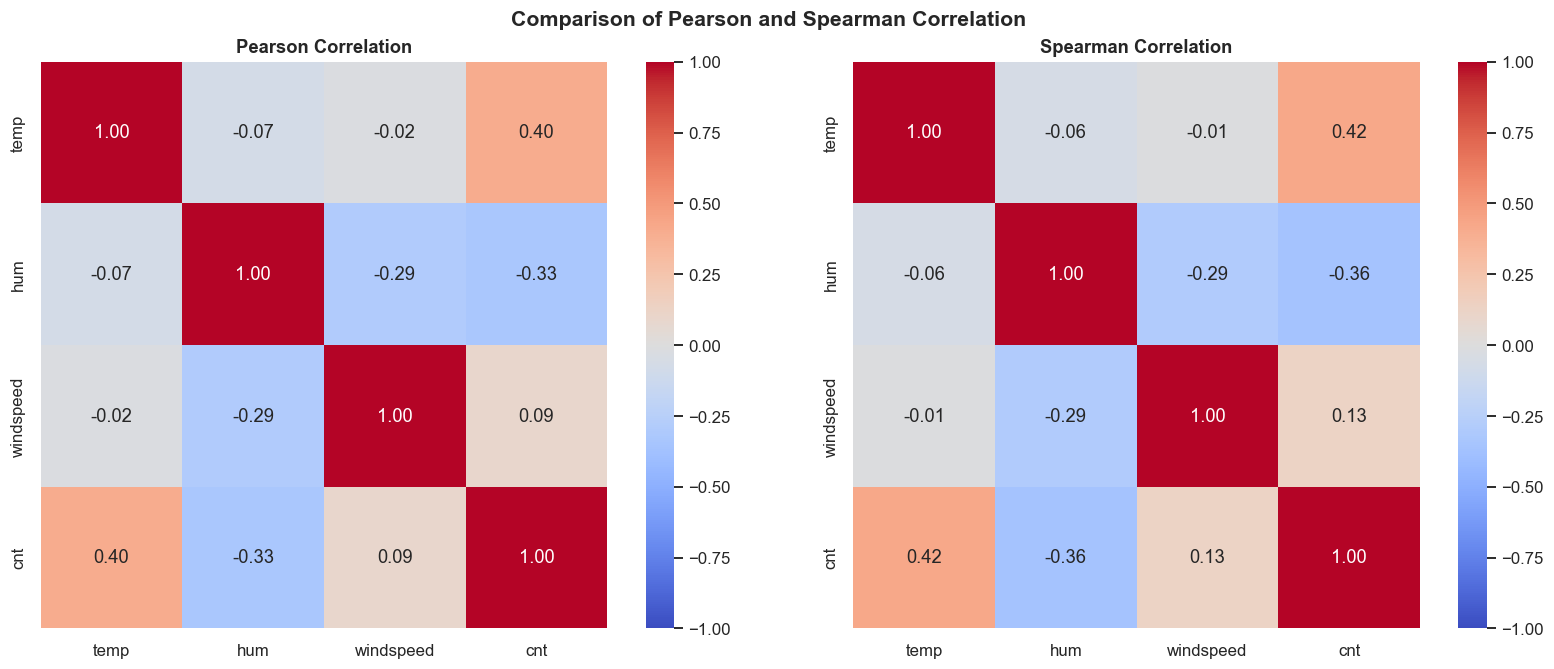

In [26]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap Pearson
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[0]
)
axes[0].set_title("Pearson Correlation")

# Heatmap Spearman
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)
axes[1].set_title("Spearman Correlation")

fig.suptitle(
    "Comparison of Pearson and Spearman Correlation",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


### 4.3.2. Quan hệ giữa các biến thời tiết và `cnt`

Do dữ liệu có 17,379 quan sát, scatter plot có thể bị chồng lấn nhiều điểm.
Hexbin được sử dụng để thể hiện mật độ quan sát.

### 4.3.2.1 temp – cnt

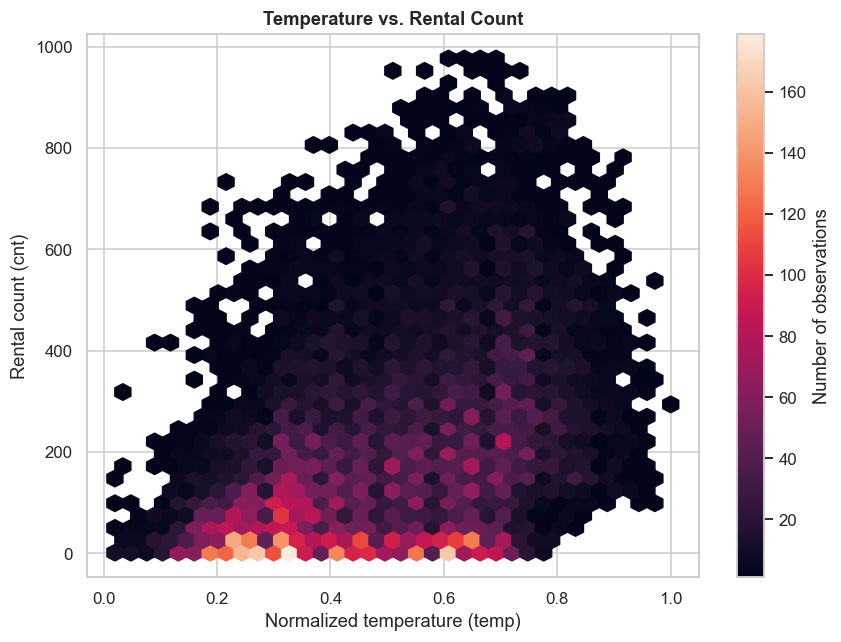

In [20]:
plt.figure(figsize=(8, 6))

plt.hexbin(
    df["temp"],
    df["cnt"],
    gridsize=35,
    mincnt=1
)

plt.colorbar(label="Number of observations")
plt.xlabel("Normalized temperature (temp)")
plt.ylabel("Rental count (cnt)")
plt.title("Temperature vs. Rental Count")

plt.tight_layout()
plt.show()

### 4.3.2.2 hum – cnt

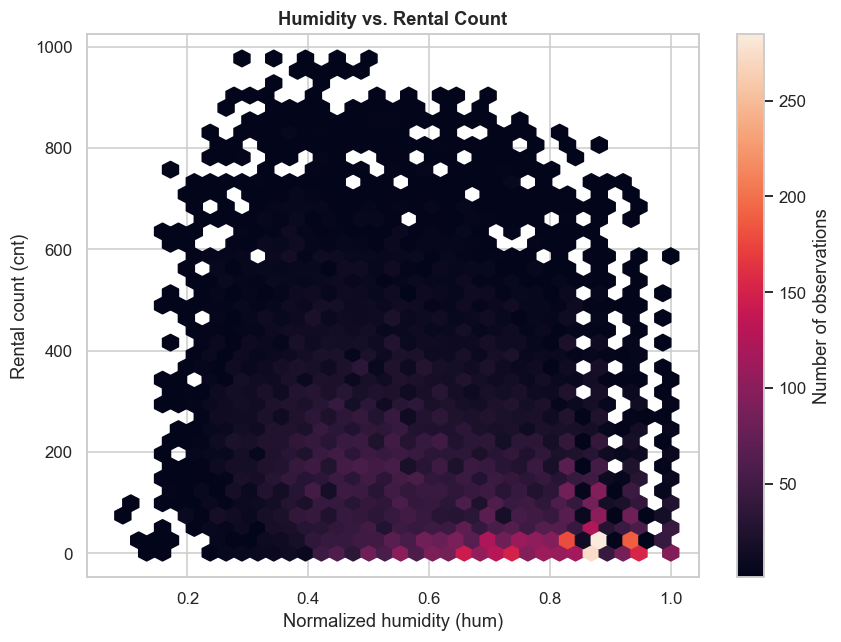

In [21]:
plt.figure(figsize=(8, 6))

plt.hexbin(
    df["hum"],
    df["cnt"],
    gridsize=35,
    mincnt=1
)

plt.colorbar(label="Number of observations")
plt.xlabel("Normalized humidity (hum)")
plt.ylabel("Rental count (cnt)")
plt.title("Humidity vs. Rental Count")

plt.tight_layout()
plt.show()

### 4.3.2.3 windspeed – cnt

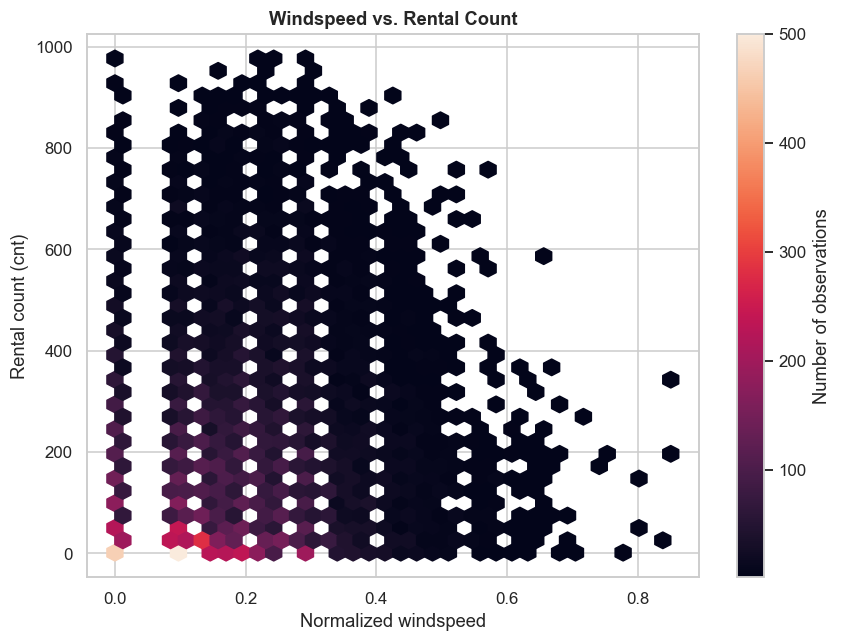

In [27]:
plt.figure(figsize=(8, 6))

plt.hexbin(
    df["windspeed"],
    df["cnt"],
    gridsize=35,
    mincnt=1
)

plt.colorbar(label="Number of observations")
plt.xlabel("Normalized windspeed")
plt.ylabel("Rental count (cnt)")
plt.title("Windspeed vs. Rental Count")

plt.tight_layout()
plt.show()

## 4.3.2.4 Trường hợp đặc biệt: `hr` – `cnt`

EDA cho thấy số lượt thuê thay đổi mạnh theo giờ trong ngày và có dạng
chu kỳ. Ngày làm việc xuất hiện hai đỉnh vào khoảng 8h và 17h, trong khi
ngày nghỉ có xu hướng đạt đỉnh vào khoảng 13h.

Do đó, quan hệ giữa `hr` và `cnt` không có dạng tuyến tính đơn giản.
Một hệ số tương quan duy nhất có thể không phản ánh đầy đủ đặc điểm này.

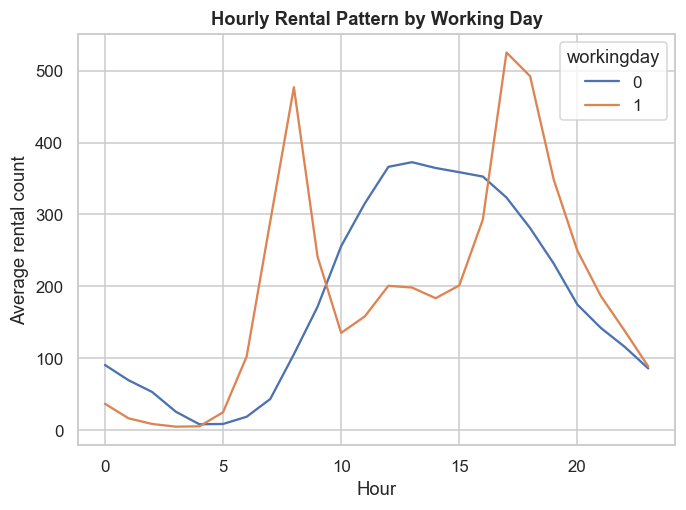

In [23]:
hourly_mean = df.groupby(["hr", "workingday"])["cnt"].mean().reset_index()

sns.lineplot(
    data=hourly_mean,
    x="hr",
    y="cnt",
    hue="workingday"
)

plt.xlabel("Hour")
plt.ylabel("Average rental count")
plt.title("Hourly Rental Pattern by Working Day")
plt.tight_layout()
plt.show()

## 4.4. Ý nghĩa thực tiễn

In [31]:
pearson_pairs = (
    pearson_corr
    .where(np.triu(np.ones(pearson_corr.shape), k=1).astype(bool))
    .stack()
    .dropna()
    .sort_values(key=abs, ascending=False)
)

pearson_pairs

temp       cnt          0.404772
hum        cnt         -0.329216
           windspeed   -0.289342
windspeed  cnt          0.093234
temp       hum         -0.073037
           windspeed   -0.023125
dtype: float64

In [32]:
spearman_pairs = (
    spearman_corr
    .where(np.triu(np.ones(spearman_corr.shape), k=1).astype(bool))
    .stack()
    .dropna()
    .sort_values(key=abs, ascending=False)
)

spearman_pairs

temp       cnt          0.423330
hum        cnt         -0.363359
           windspeed   -0.292621
windspeed  cnt          0.126629
temp       hum         -0.057130
           windspeed   -0.009719
dtype: float64

Cặp biến        |Pearson ($r$)  |Spearman ($\rho$)  |Nhận xét sơ bộ
---             |---            |---                |---
temp – cnt      |0.4048         |0.4233             |Tương quan dương mức trung bình
hum – cnt       |-0.3292        |-0.3634            |Tương quan âm mức yếu đến trung bình
hum – windspeed |-0.2893        |-0.2926            |Tương quan âm mức yếu
windspeed – cnt |0.0932         |0.1266             |Tương quan dương rất yếu
temp – hum      |-0.0730        |-0.0571            |Tương quan âm rất yếu
temp – windspeed|-0.0231        |-0.0097            |Gần như không có tương quan tuyến tính

### 4.4.1 Nhận xét

`temp – cnt`

Hệ số tương quan $(r & \rho \approx 0.40)$ cho thấy tương quan dương mức trung bình. Trong dữ liệu, nhiệt độ cao hơn có xu hướng đi kèm số lượt thuê xe cao hơn.

Tuy nhiên, điều này chưa chứng minh nhiệt độ là nguyên nhân làm nhu cầu thuê xe tăng. Thời gian, mùa, loại ngày và các yếu tố khác cũng có thể liên quan.

`hum – cnt`

Hệ số tương quan $(r & \rho \approx -0.33)$ cho thấy tương quan âm mức yếu đến trung bình. Độ ẩm cao hơn có xu hướng đi kèm số lượt thuê xe thấp hơn.

`windspeed – cnt`

Hệ số tương quan $(r & \rho \approx 0.10)$ cho thấy mối quan hệ tuyến tính khá yếu. Trong dữ liệu tổng thể, tốc độ gió không có mối liên hệ tuyến tính rõ ràng với số lượt thuê xe.

Không nên kết luận rằng gió không ảnh hưởng đến việc thuê xe; hệ số thấp chỉ cho thấy tương quan tuyến tính tổng thể yếu.

In [33]:
comparison_df["Abs_Difference"] = (
    comparison_df["Pearson"] - comparison_df["Spearman"]
).abs()

comparison_df.sort_values(
    "Abs_Difference",
    ascending=False
).round(4)

,Pair,Pearson,Spearman,Difference,Abs_Difference
4,hum – cnt,-0.3292,-0.3634,-0.0341,0.0341
5,windspeed – cnt,0.0932,0.1266,0.0334,0.0334
2,temp – cnt,0.4048,0.4233,0.0186,0.0186
0,temp – hum,-0.0730,-0.0571,0.0159,0.0159
1,temp – windspeed,-0.0231,-0.0097,0.0134,0.0134
3,hum – windspeed,-0.2893,-0.2926,-0.0033,0.0033


### 4.4.2 Các mối quan hệ đáng chú ý

Các biến tương quan rõ nhất với cnt thứ tự theo trị tuyệt đối là:

- `temp – cnt`      (0.40)
- `hum – cnt`       (0.33)
- `windspeed – cnt` (0.10)

### 4.4.3 Hạn chế
- Tương quan không chứng minh quan hệ nhân quả.

- hr có quan hệ chu kỳ với cnt; một hệ số tương quan duy nhất có thể không phản ánh đầy đủ hình dạng quan hệ.

- Dữ liệu có tự tương quan theo thời gian, với $(N_{\text{eff}}\approx1{,}479)$, thấp hơn số dòng thực tế 17.379. Điều này cần được lưu ý khi diễn giải kiểm định ý nghĩa thống kê.

## Correlation Findings Sheet

### Biến được phân tích

- `temp`
- `hum`
- `windspeed`
- `cnt`

### Biến bị loại khỏi phân tích chính

- `atemp`: tương quan rất cao với `temp` (r = 0.9877).
- `casual`, `registered`: là thành phần của `cnt`, không sử dụng làm biến độc lập.

### Kết quả chính

- Cặp biến có tương quan mạnh nhất: `temp-cnt`
- Biến có tương quan mạnh nhất với `cnt`: `temp`
- Chiều tương quan với `cnt`: `temp +`, `hum -`, `windspeed +`
- Pearson và Spearman: ABS differece:
  - `cnt-hum`:           0.0341
  - `windspeed – cnt`:   0.0334
  - `temp – cnt`:        0.0186

### Lưu ý

- `hr` có quan hệ chu kỳ với `cnt`, do đó correlation coefficient không phản ánh đầy đủ mối quan hệ này.
- Dữ liệu có tự tương quan mạnh theo thời gian.
- `N_eff ≈ 1,479`, thấp hơn đáng kể so với 17,379 quan sát.
- Correlation không chứng minh quan hệ nhân quả.
- Các outlier được giữ lại vì được xác định là quan sát hợp lệ.